# The Anatomy of a Goal: Decoding Scoring Patterns Across Europe's Top Leagues
### AI-Assisted Data Analysis Using Claude (Anthropic)

**Research Questions:**
1. What sequences of actions most frequently lead to goals?
2. What types of passes precede goals, and from where on the pitch?
3. Where do goal-scoring moves originate and terminate?
4. Which defensive formations are most vulnerable to specific attacking patterns?

**Dataset:** [Wyscout Soccer Match Event Dataset](https://www.kaggle.com/datasets/aleespinosa/soccer-match-event-dataset) — 2.46 million on-ball actions from 1,941 matches across 7 competitions (Premier League, La Liga, Serie A, Ligue 1, Bundesliga, Euro 2016, World Cup 2018), converted to SPADL format with VAEP-style goal-scoring labels.

**AI Tool:** Claude by Anthropic — used for analysis design, code generation, statistical interpretation, and iterative refinement of visualizations.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                             classification_report, confusion_matrix)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'axes.titleweight': 'bold'
})

DATA_PATH = r'C:\\Users\\abdal\\Downloads\\Assigment\\04_Dataset'

SHOT_TYPES = ['shot', 'shot_freekick', 'shot_penalty']

def draw_pitch(ax, pitch_color='#3a7d3a', line_color='white', linewidth=1.8):
    """Draw a football pitch on a matplotlib axes. Teams attack toward x=105."""
    # Explicit green pitch surface (works even with axis off)
    ax.add_patch(patches.Rectangle((0, 0), 105, 68, facecolor=pitch_color, edgecolor='none', zorder=0))
    # Outer boundary
    ax.add_patch(patches.Rectangle((0, 0), 105, 68, fill=False, ec=line_color, lw=linewidth, zorder=1))
    # Centre line
    ax.plot([52.5, 52.5], [0, 68], color=line_color, lw=linewidth, zorder=1)
    # Centre circle
    ax.add_patch(patches.Circle((52.5, 34), 9.15, fill=False, ec=line_color, lw=linewidth, zorder=1))
    ax.plot(52.5, 34, 'o', color=line_color, ms=4, zorder=1)
    # Left penalty area
    ax.add_patch(patches.Rectangle((0, 13.84), 16.5, 40.32, fill=False, ec=line_color, lw=linewidth, zorder=1))
    ax.add_patch(patches.Rectangle((0, 24.84), 5.5, 18.32, fill=False, ec=line_color, lw=linewidth, zorder=1))
    ax.add_patch(patches.Arc((11, 34), 18.3, 18.3, angle=0, theta1=-53.13, theta2=53.13, color=line_color, lw=linewidth, zorder=1))
    ax.plot(11, 34, 'o', color=line_color, ms=4, zorder=1)
    # Right penalty area
    ax.add_patch(patches.Rectangle((88.5, 13.84), 16.5, 40.32, fill=False, ec=line_color, lw=linewidth, zorder=1))
    ax.add_patch(patches.Rectangle((99.5, 24.84), 5.5, 18.32, fill=False, ec=line_color, lw=linewidth, zorder=1))
    ax.add_patch(patches.Arc((94, 34), 18.3, 18.3, angle=0, theta1=126.87, theta2=233.13, color=line_color, lw=linewidth, zorder=1))
    ax.plot(94, 34, 'o', color=line_color, ms=4, zorder=1)
    # Goals
    ax.add_patch(patches.Rectangle((-2, 30.34), 2, 7.32, fill=False, ec=line_color, lw=linewidth+0.5, zorder=1))
    ax.add_patch(patches.Rectangle((105, 30.34), 2, 7.32, fill=False, ec=line_color, lw=linewidth+0.5, zorder=1))
    ax.set_xlim(-4, 109)
    ax.set_ylim(-2, 70)
    ax.set_aspect('equal')
    ax.axis('off')

print("Setup complete. Libraries loaded.")

Setup complete. Libraries loaded.


## 1. Loading the Pitch: Dataset Description & Preparation

**Source:** The dataset originates from the [Wyscout](https://wyscout.com/) platform, a professional football analytics provider. It was published on Kaggle and provides granular event-level data for every on-ball action.

**Core files (row-aligned, 2,462,726 rows each):**
| File | Description |
|------|-------------|
| `actions.csv` | Every on-ball action: coordinates (x/y), type, result, body part |
| `features.csv` | Engineered spatial features: 3-action sequences with distance/angle metrics |
| `labels.csv` | Binary labels: `scores` and `concedes` (did this action sequence lead to a goal?) |

**Supporting files:** `games.csv` (1,941 matches), `teams.csv` (142 teams), `players.csv` (3,603 players), `playerank.csv` (46,897 match ratings), `player_games.csv` (53,715 appearances), `competitions.csv` (7 competitions).

In [2]:
# Load primary datasets
print("Loading actions.csv ...")
actions = pd.read_csv(f'{DATA_PATH}/actions.csv', index_col=0)
print(f"  actions: {actions.shape}")

print("Loading labels.csv ...")
labels = pd.read_csv(f'{DATA_PATH}/labels.csv', index_col=0)
print(f"  labels: {labels.shape}")

# Load features.csv with only the columns we need (full file is 2.2 GB)
feature_cols = [
    'type_name-1', 'type_name-2', 'result_name-1', 'bodypart_name-1',
    'start_x-1', 'start_y-1', 'end_x-1', 'end_y-1',
    'start_x_norm-0', 'start_y_norm-0',
    'start_distance_to_goal-0', 'start_angle_to_goal-0',
    'end_x_norm-0', 'end_y_norm-0',
    'end_distance_to_goal-0', 'end_angle_to_goal-0',
    'diff_x-0', 'diff_y-0', 'distance_covered-0',
    'start_x_norm-1', 'start_y_norm-1',
    'end_x_norm-1', 'end_y_norm-1',
    'start_distance_to_goal-1', 'start_angle_to_goal-1',
    'team-1', 'team-2',
    'type_id-0', 'type_id-1', 'bodypart_id-0',
    'time_sequence_pre'
]
print("Loading features.csv (selected columns only) ...")
features = pd.read_csv(f'{DATA_PATH}/features.csv', usecols=feature_cols)
print(f"  features: {features.shape}")

# Merge all three by index
df = pd.concat([actions.reset_index(drop=True),
                features.reset_index(drop=True),
                labels.reset_index(drop=True)], axis=1)
del actions, features, labels  # free memory

# Load and merge metadata
games = pd.read_csv(f'{DATA_PATH}/games.csv', index_col=0)
competitions = pd.read_csv(f'{DATA_PATH}/competitions.csv')
teams = pd.read_csv(f'{DATA_PATH}/teams.csv')

df = df.merge(games[['game_id','competition_id','game_date','home_team_id','away_team_id']],
              on='game_id', how='left')
df = df.merge(competitions[['wyId','name']].rename(columns={'wyId':'competition_id','name':'competition_name'}),
              on='competition_id', how='left')
df = df.merge(teams[['wyId','name']].rename(columns={'wyId':'team_id','name':'team_name'}),
              on='team_id', how='left')

# Direction-normalized pitch coordinates for visualization.
# In this SPADL dataset, start_x_norm-0 close to 0 = near the attacking goal.
# Flip so attacks point RIGHT (toward x=105) on every pitch chart.
df['pitch_x'] = (1 - df['start_x_norm-0']) * 105
df['pitch_y'] = df['start_y_norm-0'] * 68

# REAL distance/angle from the attacking goal.
# (The features.csv 'start_distance_to_goal-0' measures distance to the FAR goal at x=105,
#  so we recompute the true attacking distance from the normalized coordinates.)
df['attack_dist'] = np.sqrt((df['start_x_norm-0'] * 105)**2 + (df['start_y_norm-0'] * 68 - 34)**2)
df['attack_angle'] = np.degrees(np.arctan2(7.32, 2 * df['attack_dist'] + 1e-6))  # visible goal angle approx

print(f"\nFinal merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Competitions: {df['competition_name'].nunique()}")
print(f"Matches: {df['game_id'].nunique()}")
print(f"Teams: {df['team_name'].nunique()}")
print(f"Players: {df['player_id'].nunique()}")

Loading actions.csv ...


  actions: (2462726, 17)
Loading labels.csv ...


  labels: (2462726, 2)
Loading features.csv (selected columns only) ...


  features: (2462726, 31)



Final merged dataset: 2,462,726 rows x 60 columns


Memory usage: 2.34 GB
Competitions: 7
Matches: 1941


Teams: 142
Players: 3031


In [3]:
# ── Missing Value Detection ──
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string())
    print(f"\nNote: Missing values in '-1' and '-2' suffix columns are expected —")
    print("they represent the 1st and 2nd actions of each match half (no prior history).")
else:
    print("No missing values found in the dataset.")

print("\n" + "=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Action type distribution
print("\nAction Type Distribution:")
print(df['type_name'].value_counts().to_string())

# Goal identification
goals_mask = (df['type_name'].isin(SHOT_TYPES)) & (df['result_name'] == 'success') & (df['scores'] == True)
total_goals = goals_mask.sum()
total_matches = df['game_id'].nunique()
print(f"\n{'─' * 40}")
print(f"Total actions:    {len(df):>12,}")
print(f"Total matches:    {total_matches:>12,}")
print(f"Total goals:      {total_goals:>12,}")
print(f"Goals per match:  {total_goals/total_matches:>12.2f}")
print(f"{'─' * 40}")

# VAEP label distribution
print(f"\nVAEP Labels (scores=True marks ALL actions in a goal-scoring sequence):")
print(f"  scores=True:   {df['scores'].sum():>10,} actions ({df['scores'].mean()*100:.2f}%)")
print(f"  concedes=True: {df['concedes'].sum():>10,} actions ({df['concedes'].mean()*100:.2f}%)")

# Numerical summary
print("\nNumerical Summary (key spatial features):")
print(df[['start_x','start_y','end_x','end_y','attack_dist','attack_angle']].describe().round(2).to_string())

MISSING VALUE ANALYSIS


                          Missing Count  Percentage (%)
original_event_id                168600            6.85
time_sequence_pre                  3882            0.16
type_name-2                        3882            0.16
start_x-1                          1941            0.08
start_y-1                          1941            0.08
type_id-1                          1941            0.08
type_name-1                        1941            0.08
end_x-1                            1941            0.08
end_y-1                            1941            0.08
bodypart_name-1                    1941            0.08
result_name-1                      1941            0.08
start_y_norm-1                     1941            0.08
start_x_norm-1                     1941            0.08
start_distance_to_goal-1           1941            0.08
start_angle_to_goal-1              1941            0.08
end_x_norm-1                       1941            0.08
end_y_norm-1                       1941         


────────────────────────────────────────
Total actions:       2,462,726
Total matches:           1,941
Total goals:             5,104
Goals per match:          2.63
────────────────────────────────────────

VAEP Labels (scores=True marks ALL actions in a goal-scoring sequence):
  scores=True:       38,299 actions (1.56%)
  concedes=True:     12,399 actions (0.50%)

Numerical Summary (key spatial features):


          start_x     start_y       end_x       end_y  attack_dist  attack_angle
count  2462726.00  2462726.00  2462726.00  2462726.00   2462726.00    2462726.00
mean        54.85       33.91       47.53       33.83        59.59          4.32
std         25.43       20.14       25.44       20.17        22.55          2.85
min          0.00        0.00        0.00        0.00         0.00          1.90
25%         34.65       16.32       28.35       16.32        41.36          2.74
50%         56.70       34.00       45.15       34.00        59.19          3.54
75%         73.50       51.68       68.25       51.68        76.48          5.06
max        105.00       68.00      105.00       68.00       110.37         90.00


## 2. The Geography of Goals: Where Attacks Begin and End

Not all pitch zones are created equal. We map where goal-scoring shots are taken, where the build-up sequences originate, and where the final pass is delivered — revealing the spatial DNA of goal-scoring.

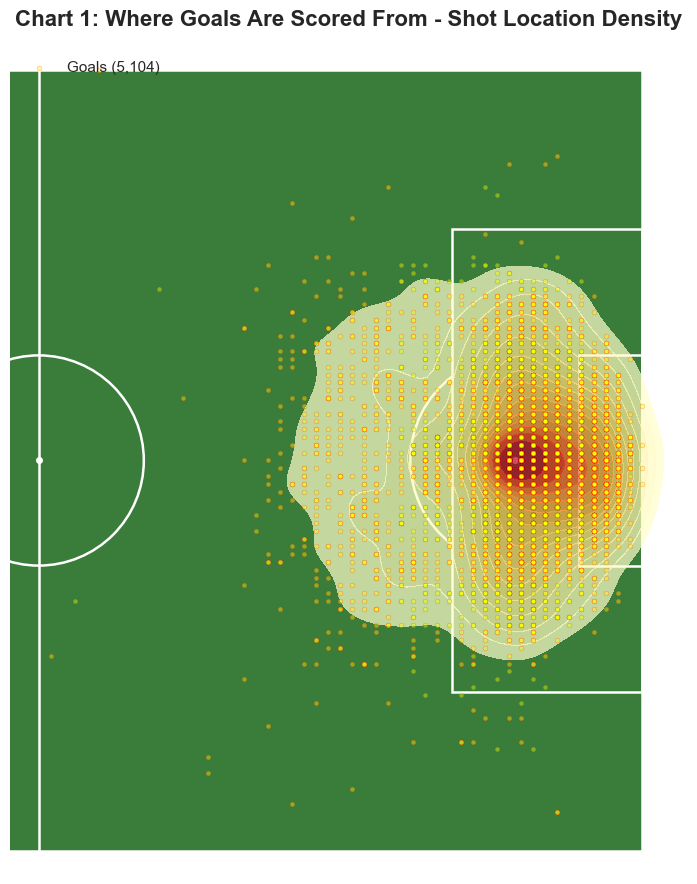

Total shots: 45,937 | Goals: 5,104 | Conversion rate: 11.1%
Average goal shot position: (94.0m, 33.7m)
(Goal is at x=105m; most goals scored from very close range)


In [4]:
# CHART 1: Shot Location Heatmap on Pitch (direction-normalized)
fig, ax = plt.subplots(figsize=(14, 9))
draw_pitch(ax)

# All shots (using direction-normalized coordinates so all attacks go toward x=105)
all_shots = df[df['type_name'].isin(SHOT_TYPES)]
goals = all_shots[(all_shots['result_name'] == 'success') & (all_shots['scores'] == True)]

# Goals as KDE heatmap (shows density clearly)
if len(goals) > 10:
    sns.kdeplot(x=goals['pitch_x'], y=goals['pitch_y'],
                fill=True, cmap='YlOrRd', alpha=0.7, levels=15, ax=ax, zorder=3,
                thresh=0.05)

# Goals as scatter on top
ax.scatter(goals['pitch_x'], goals['pitch_y'],
           c='yellow', s=12, alpha=0.4, edgecolors='red', linewidth=0.3,
           zorder=4, label=f'Goals ({len(goals):,})')

ax.set_xlim(50, 109)
ax.set_title('Chart 1: Where Goals Are Scored From - Shot Location Density',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

print(f"Total shots: {len(all_shots):,} | Goals: {len(goals):,} | Conversion rate: {len(goals)/len(all_shots)*100:.1f}%")
print(f"Average goal shot position: ({goals['pitch_x'].mean():.1f}m, {goals['pitch_y'].mean():.1f}m)")
print(f"(Goal is at x=105m; most goals scored from very close range)")

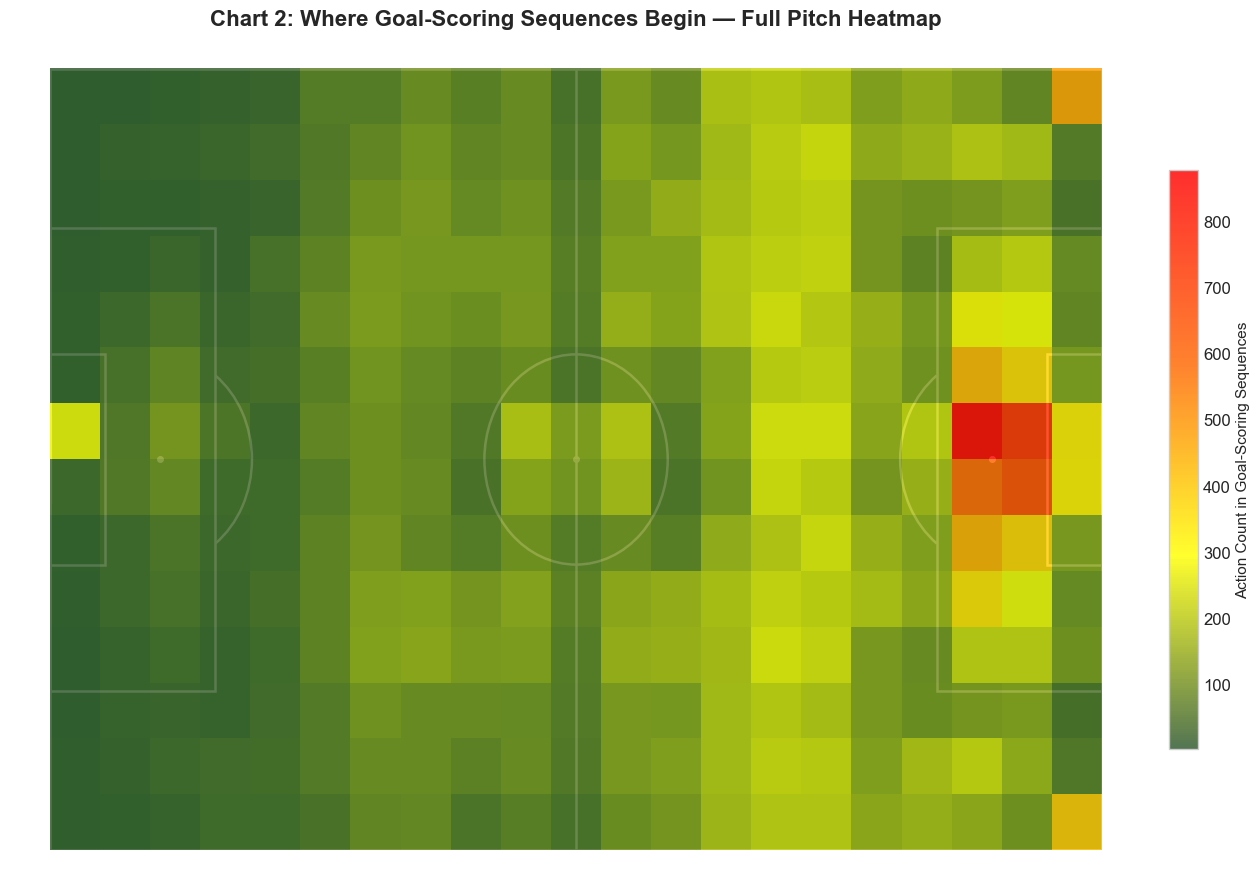

Total actions in scoring sequences: 38,299
Average starting position: (69.4m, 34.0m)


In [5]:
# CHART 2: Where Goal-Scoring Sequences Originate (Full Pitch Heatmap)
fig, ax = plt.subplots(figsize=(14, 9))
draw_pitch(ax)

scoring_actions = df[df['scores'] == True]

heatmap, xedges, yedges = np.histogram2d(
    scoring_actions['pitch_x'], scoring_actions['pitch_y'],
    bins=[21, 14], range=[[0, 105], [0, 68]]
)

cmap = LinearSegmentedColormap.from_list('pitch_heat', ['#2d572c', '#ffff00', '#ff6600', '#ff0000'])
im = ax.imshow(heatmap.T, origin='lower', extent=[0, 105, 0, 68],
               cmap=cmap, alpha=0.82, aspect='auto', zorder=2)
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Action Count in Goal-Scoring Sequences', fontsize=11)

ax.set_title('Chart 2: Where Goal-Scoring Sequences Begin — Full Pitch Heatmap',
             fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"Total actions in scoring sequences: {len(scoring_actions):,}")
print(f"Average starting position: ({scoring_actions['pitch_x'].mean():.1f}m, {scoring_actions['pitch_y'].mean():.1f}m)")

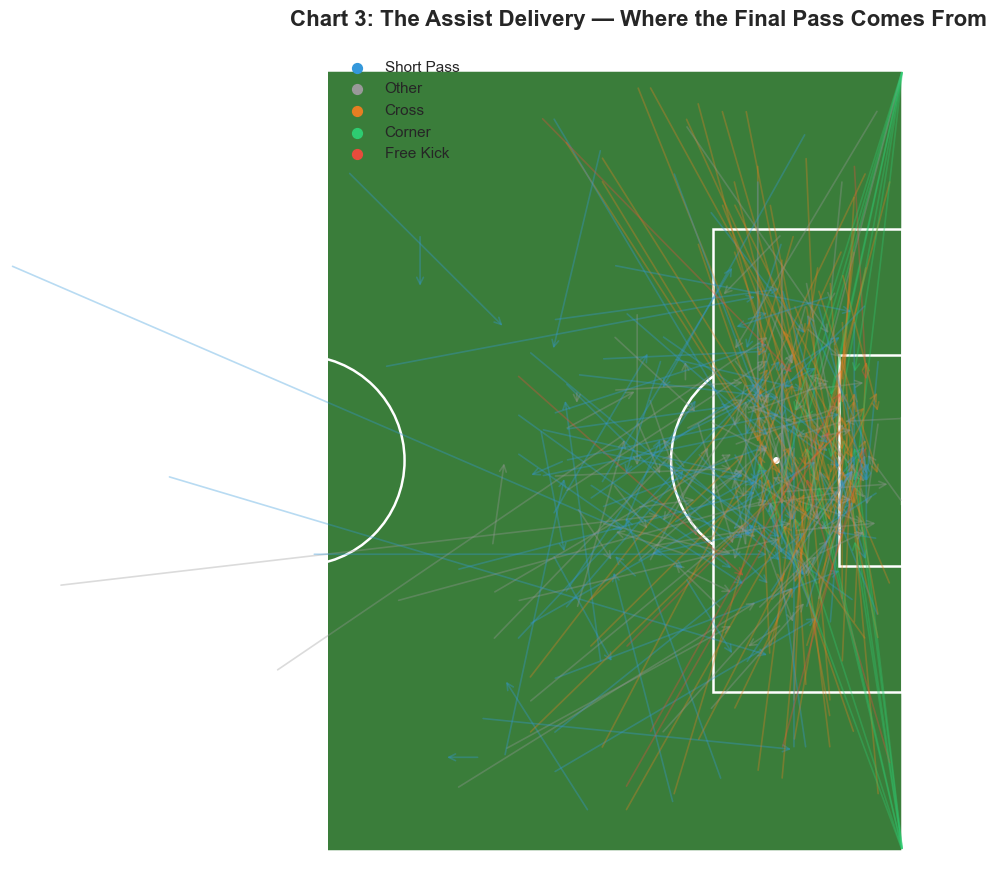

Top 5 assist action types (% of goals):
  pass                  30.4%
  dribble               18.1%
  cross                 18.0%
  foul                  11.0%
  keeper_save            5.3%


In [6]:
# CHART 3: Assist Pass Vectors — Arrow Plot (direction-normalized)
fig, ax = plt.subplots(figsize=(14, 9))
draw_pitch(ax)

# Goal-scoring shots with previous action data
goal_shots = df[
    (df['type_name'].isin(SHOT_TYPES)) &
    (df['result_name'] == 'success') &
    (df['scores'] == True) &
    (df['start_x_norm-1'].notna())
].copy()

# Convert normalized coords to pitch coordinates for previous action (flip so attack goes right)
goal_shots['prev_start_x'] = (1 - goal_shots['start_x_norm-1']) * 105
goal_shots['prev_start_y'] = goal_shots['start_y_norm-1'] * 68
goal_shots['prev_end_x'] = (1 - goal_shots['end_x_norm-1']) * 105
goal_shots['prev_end_y'] = goal_shots['end_y_norm-1'] * 68

# Color-code by previous action type
color_map = {
    'pass': '#3498db',
    'cross': '#e67e22',
    'corner_crossed': '#2ecc71',
    'corner_short': '#2ecc71',
    'freekick_crossed': '#e74c3c',
    'freekick_short': '#e74c3c',
}
label_map = {
    'pass': 'Short Pass', 'cross': 'Cross',
    'corner_crossed': 'Corner', 'corner_short': 'Corner',
    'freekick_crossed': 'Free Kick', 'freekick_short': 'Free Kick',
}

# Subsample for readability
sample = goal_shots.sample(n=min(350, len(goal_shots)), random_state=42)

plotted_labels = set()
for _, row in sample.iterrows():
    prev_type = row['type_name-1']
    color = color_map.get(prev_type, '#999999')
    label = label_map.get(prev_type, 'Other')
    show_label = label if label not in plotted_labels else None
    if show_label:
        plotted_labels.add(label)

    ax.annotate('', xy=(row['prev_end_x'], row['prev_end_y']),
                xytext=(row['prev_start_x'], row['prev_start_y']),
                arrowprops=dict(arrowstyle='->', color=color, alpha=0.35, lw=1.2),
                zorder=3)
    if show_label:
        ax.scatter([], [], c=color, s=50, label=show_label)

ax.set_xlim(55, 109)
ax.set_title('Chart 3: The Assist Delivery — Where the Final Pass Comes From',
             fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

# Stats
prev_types = goal_shots['type_name-1'].value_counts(normalize=True).head(5) * 100
print("Top 5 assist action types (% of goals):")
for t, pct in prev_types.items():
    print(f"  {t:20s} {pct:5.1f}%")

## 3. The Build-Up: Action Sequences That Produce Goals

A goal is never an isolated event — it is the climax of a sequence. By analyzing the three consecutive actions before each goal, we reveal the tactical patterns that unlock defenses.

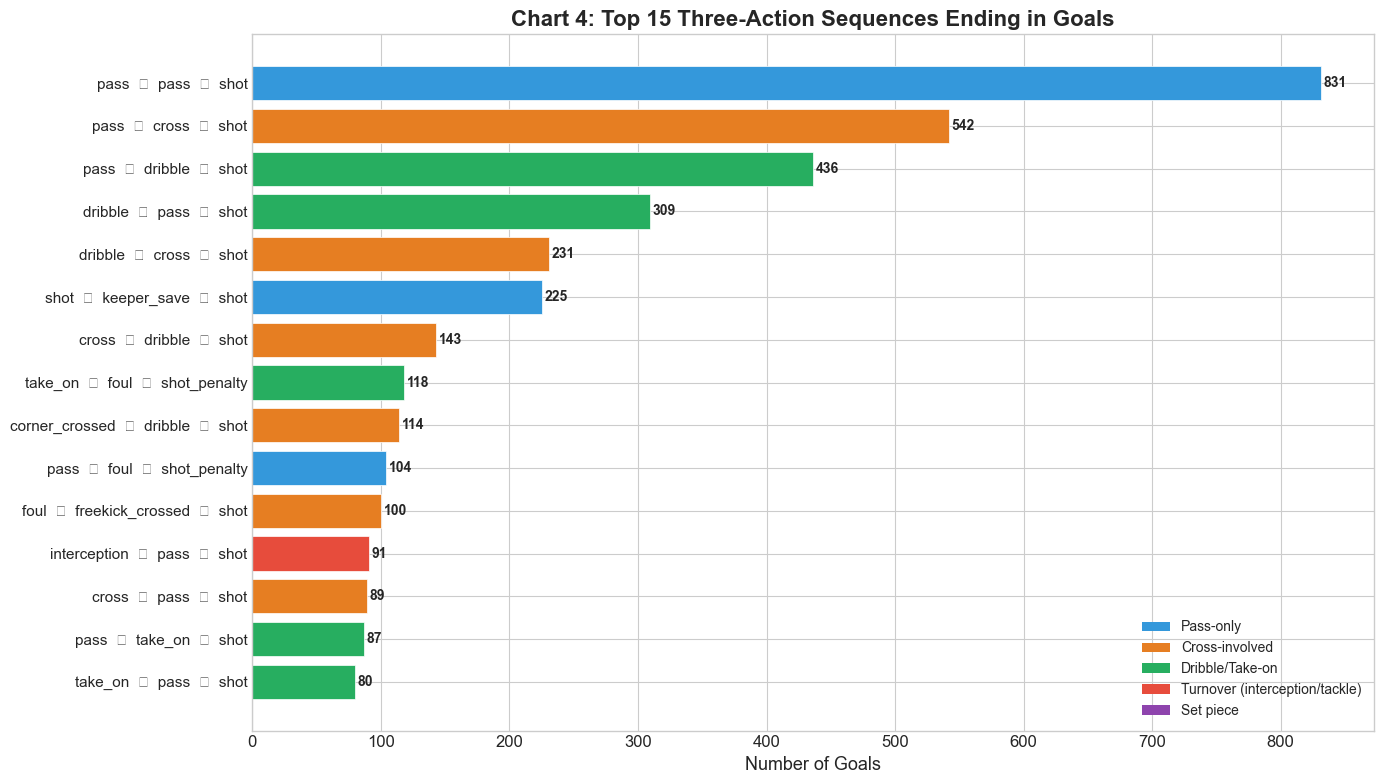

In [7]:
# CHART 4: Top 15 Three-Action Sequences Leading to Goals
goal_seqs = df[
    (df['type_name'].isin(SHOT_TYPES)) &
    (df['result_name'] == 'success') &
    (df['scores'] == True) &
    (df['type_name-1'].notna()) &
    (df['type_name-2'].notna())
].copy()

goal_seqs['sequence'] = (goal_seqs['type_name-2'].astype(str) + '  ➜  ' +
                          goal_seqs['type_name-1'].astype(str) + '  ➜  ' +
                          goal_seqs['type_name'].astype(str))

seq_counts = goal_seqs['sequence'].value_counts().head(15)

# Color by category
def seq_color(seq):
    if 'cross' in seq: return '#e67e22'
    if 'dribble' in seq or 'take_on' in seq: return '#27ae60'
    if 'interception' in seq or 'tackle' in seq: return '#e74c3c'
    if 'corner' in seq or 'freekick' in seq: return '#8e44ad'
    return '#3498db'

colors = [seq_color(s) for s in seq_counts.index]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(seq_counts)), seq_counts.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(seq_counts)))
ax.set_yticklabels(seq_counts.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Number of Goals', fontsize=13)
ax.set_title('Chart 4: Top 15 Three-Action Sequences Ending in Goals', fontsize=16, fontweight='bold')

for bar, val in zip(bars, seq_counts.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', label='Pass-only'),
    Patch(facecolor='#e67e22', label='Cross-involved'),
    Patch(facecolor='#27ae60', label='Dribble/Take-on'),
    Patch(facecolor='#e74c3c', label='Turnover (interception/tackle)'),
    Patch(facecolor='#8e44ad', label='Set piece'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

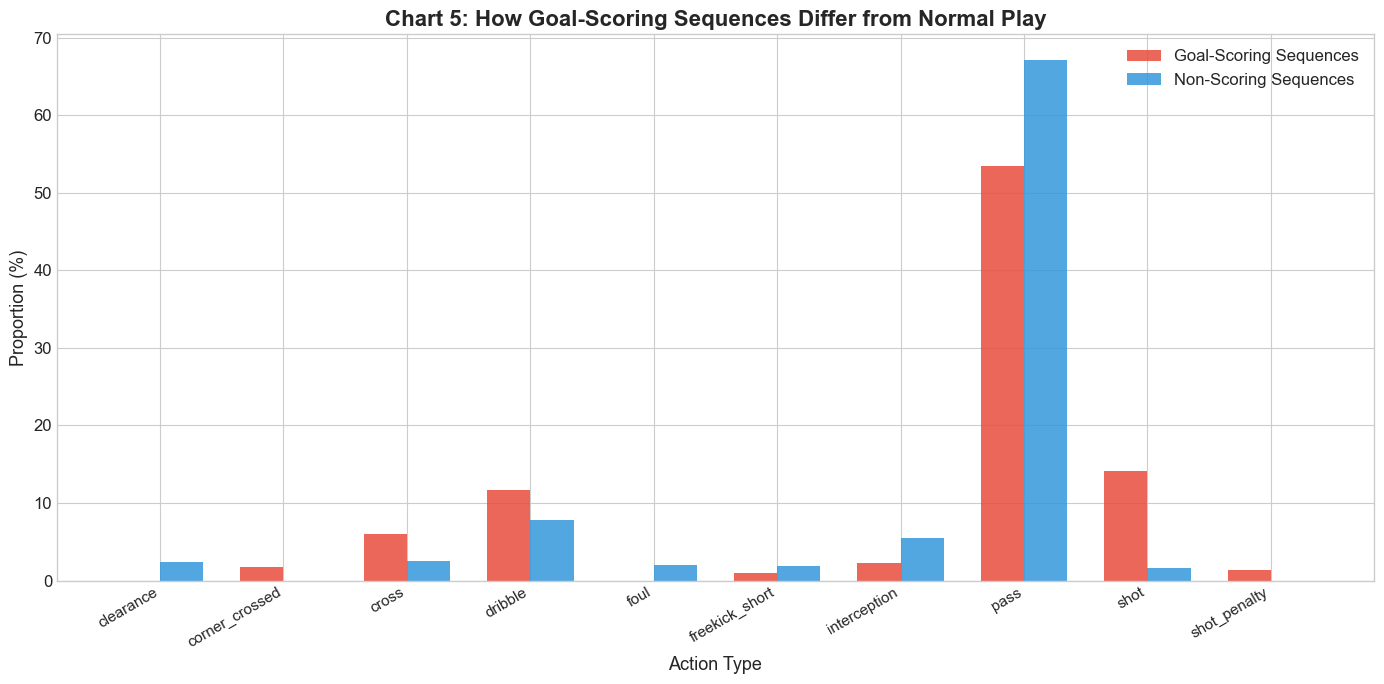

Over/under-representation in goal-scoring sequences vs normal play:
  clearance               0.0% vs   2.3%  → 0.00x  (UNDER)
  cross                   6.1% vs   2.5%  → 2.45x  (OVER)
  dribble                11.7% vs   7.8%  → 1.49x  (OVER)
  foul                    0.0% vs   2.0%  → 0.00x  (UNDER)
  freekick_short          1.0% vs   1.9%  → 0.53x  (UNDER)
  interception            2.3% vs   5.5%  → 0.42x  (UNDER)
  pass                   53.4% vs  67.1%  → 0.80x  (UNDER)
  shot                   14.1% vs   1.6%  → 9.06x  (OVER)


In [8]:
# CHART 5: Action Type Distribution — Scoring vs Non-Scoring Sequences
scoring_dist = df[df['scores'] == True]['type_name'].value_counts(normalize=True).head(10) * 100
non_scoring_dist = df[df['scores'] == False]['type_name'].value_counts(normalize=True).head(10) * 100

all_types = scoring_dist.index.union(non_scoring_dist.index)[:10]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(all_types))
width = 0.35

bars1 = ax.bar(x - width/2, [scoring_dist.get(t, 0) for t in all_types],
               width, label='Goal-Scoring Sequences', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, [non_scoring_dist.get(t, 0) for t in all_types],
               width, label='Non-Scoring Sequences', color='#3498db', alpha=0.85)

ax.set_xlabel('Action Type', fontsize=13)
ax.set_ylabel('Proportion (%)', fontsize=13)
ax.set_title('Chart 5: How Goal-Scoring Sequences Differ from Normal Play', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(all_types, rotation=30, ha='right', fontsize=11)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Compute over-representation
print("Over/under-representation in goal-scoring sequences vs normal play:")
for t in all_types:
    s = scoring_dist.get(t, 0)
    ns = non_scoring_dist.get(t, 0)
    if ns > 0:
        ratio = s / ns
        direction = "OVER" if ratio > 1.1 else ("UNDER" if ratio < 0.9 else "similar")
        print(f"  {t:20s}  {s:5.1f}% vs {ns:5.1f}%  → {ratio:.2f}x  ({direction})")

## 4. The Final Touch: Pass Types and Body Parts Before Goals

The last pass before a goal determines whether an attack converts. We investigate which delivery methods and which body parts produce the highest goal returns.

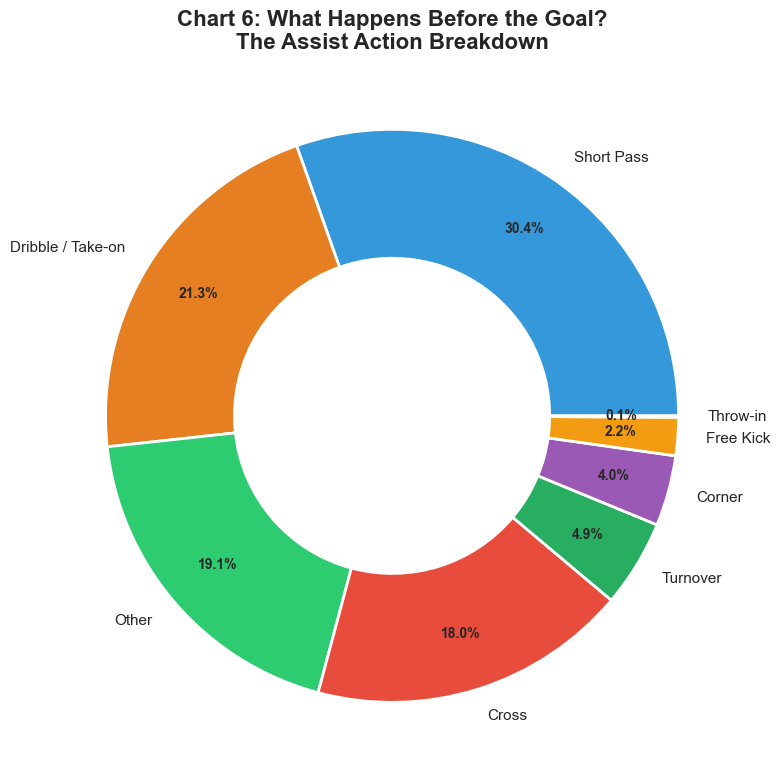

Total goals with identifiable assist action: 5,104


In [9]:
# CHART 6: Pre-Goal Assist Action Breakdown (Donut Chart)
goal_shots = df[
    (df['type_name'].isin(SHOT_TYPES)) &
    (df['result_name'] == 'success') &
    (df['scores'] == True) &
    (df['type_name-1'].notna())
]

# Categorize the assist action
def categorize_assist(t):
    if t == 'pass': return 'Short Pass'
    if t == 'cross': return 'Cross'
    if t in ('corner_crossed', 'corner_short'): return 'Corner'
    if t in ('freekick_crossed', 'freekick_short'): return 'Free Kick'
    if t in ('dribble', 'take_on'): return 'Dribble / Take-on'
    if t in ('interception', 'tackle'): return 'Turnover'
    if t == 'throw_in': return 'Throw-in'
    return 'Other'

assist_cats = goal_shots['type_name-1'].apply(categorize_assist).value_counts()

colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#27ae60', '#9b59b6', '#f39c12', '#95a5a6']

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    assist_cats.values, labels=assist_cats.index,
    autopct='%1.1f%%', pctdistance=0.8,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2),
    colors=colors[:len(assist_cats)],
    textprops={'fontsize': 11}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')

ax.set_title('Chart 6: What Happens Before the Goal?\nThe Assist Action Breakdown',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total goals with identifiable assist action: {len(goal_shots):,}")

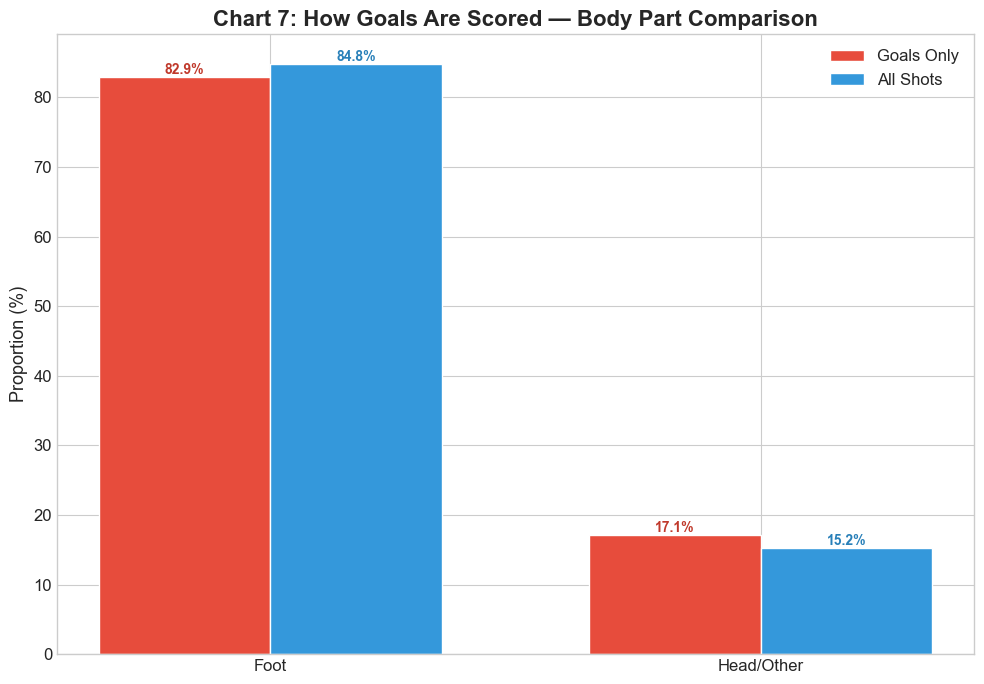

Conversion rate by body part:
  foot           4231 /  38951 =  10.9%
  head/other      873 /   6986 =  12.5%


In [10]:
# CHART 7: Body Part Distribution — Goals vs All Shots
all_shots = df[df['type_name'].isin(SHOT_TYPES)]
goals = all_shots[(all_shots['result_name'] == 'success') & (all_shots['scores'] == True)]

body_goals = goals['bodypart_name'].value_counts(normalize=True) * 100
body_all = all_shots['bodypart_name'].value_counts(normalize=True) * 100

parts = ['foot', 'head', 'head/other', 'other']
parts = [p for p in parts if p in body_goals.index or p in body_all.index]

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(parts))
width = 0.35

ax.bar(x - width/2, [body_goals.get(p, 0) for p in parts], width,
       label='Goals Only', color='#e74c3c', edgecolor='white')
ax.bar(x + width/2, [body_all.get(p, 0) for p in parts], width,
       label='All Shots', color='#3498db', edgecolor='white')

# Annotate percentages
for i, p in enumerate(parts):
    g_val = body_goals.get(p, 0)
    a_val = body_all.get(p, 0)
    ax.text(i - width/2, g_val + 0.5, f'{g_val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#c0392b')
    ax.text(i + width/2, a_val + 0.5, f'{a_val:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#2980b9')

ax.set_ylabel('Proportion (%)', fontsize=13)
ax.set_title('Chart 7: How Goals Are Scored — Body Part Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([p.title() for p in parts], fontsize=12)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Conversion rate by body part
print("Conversion rate by body part:")
for p in parts:
    total = len(all_shots[all_shots['bodypart_name'] == p])
    scored = len(goals[goals['bodypart_name'] == p])
    if total > 0:
        print(f"  {p:12s}  {scored:>5} / {total:>6} = {scored/total*100:5.1f}%")

## 5. Distance and Angle: The Physics of Goal Scoring

How far from goal and at what angle do the most dangerous attacks develop? This section quantifies the spatial factors that determine whether a shot finds the net.

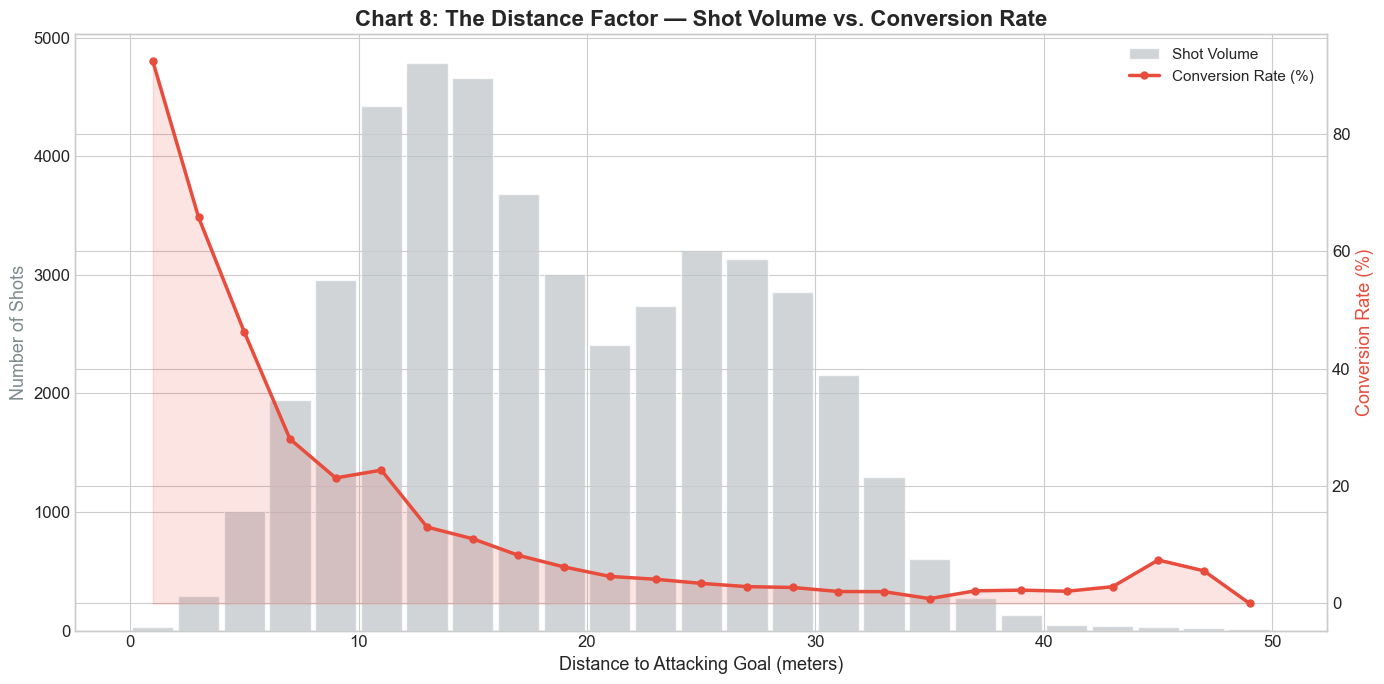

Conversion rates by zone:
  Close range (0-12m):   26.9%  (2868 goals from 10661 shots)
  Mid range (12-25m):     8.4%  (1912 goals from 22856 shots)
  Long range (25m+):      2.6%  (324 goals from 12420 shots)


In [11]:
# CHART 8: Shot Distance vs Scoring Probability (real attacking distance)
shots = df[df['type_name'].isin(SHOT_TYPES)].copy()
shots['is_goal'] = ((shots['result_name'] == 'success') & (shots['scores'] == True)).astype(int)

# Use real distance from the attacking goal
bins = np.arange(0, 52, 2)
shots['dist_bin'] = pd.cut(shots['attack_dist'], bins=bins, labels=bins[:-1]+1)
shots['dist_bin'] = shots['dist_bin'].astype(float)

binned = shots.groupby('dist_bin').agg(
    total=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).dropna()
binned = binned[binned['total'] >= 10]  # need enough shots for meaningful %
binned['conversion'] = binned['goals'] / binned['total'] * 100

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

ax1.bar(binned.index, binned['total'], width=1.8, color='#bdc3c7', alpha=0.7,
        edgecolor='white', label='Shot Volume', zorder=2)
ax2.plot(binned.index, binned['conversion'], color='#e74c3c', linewidth=2.5,
         marker='o', markersize=5, label='Conversion Rate (%)', zorder=3)
ax2.fill_between(binned.index, binned['conversion'], alpha=0.15, color='#e74c3c')

ax1.set_xlabel('Distance to Attacking Goal (meters)', fontsize=13)
ax1.set_ylabel('Number of Shots', fontsize=13, color='#7f8c8d')
ax2.set_ylabel('Conversion Rate (%)', fontsize=13, color='#e74c3c')
ax1.set_title('Chart 8: The Distance Factor — Shot Volume vs. Conversion Rate',
              fontsize=16, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)
plt.tight_layout()
plt.show()

close = shots[shots['attack_dist'] <= 12]
mid = shots[(shots['attack_dist'] > 12) & (shots['attack_dist'] <= 25)]
long_r = shots[shots['attack_dist'] > 25]
print(f"Conversion rates by zone:")
print(f"  Close range (0-12m):  {close['is_goal'].mean()*100:5.1f}%  ({close['is_goal'].sum()} goals from {len(close)} shots)")
print(f"  Mid range (12-25m):   {mid['is_goal'].mean()*100:5.1f}%  ({mid['is_goal'].sum()} goals from {len(mid)} shots)")
print(f"  Long range (25m+):    {long_r['is_goal'].mean()*100:5.1f}%  ({long_r['is_goal'].sum()} goals from {len(long_r)} shots)")

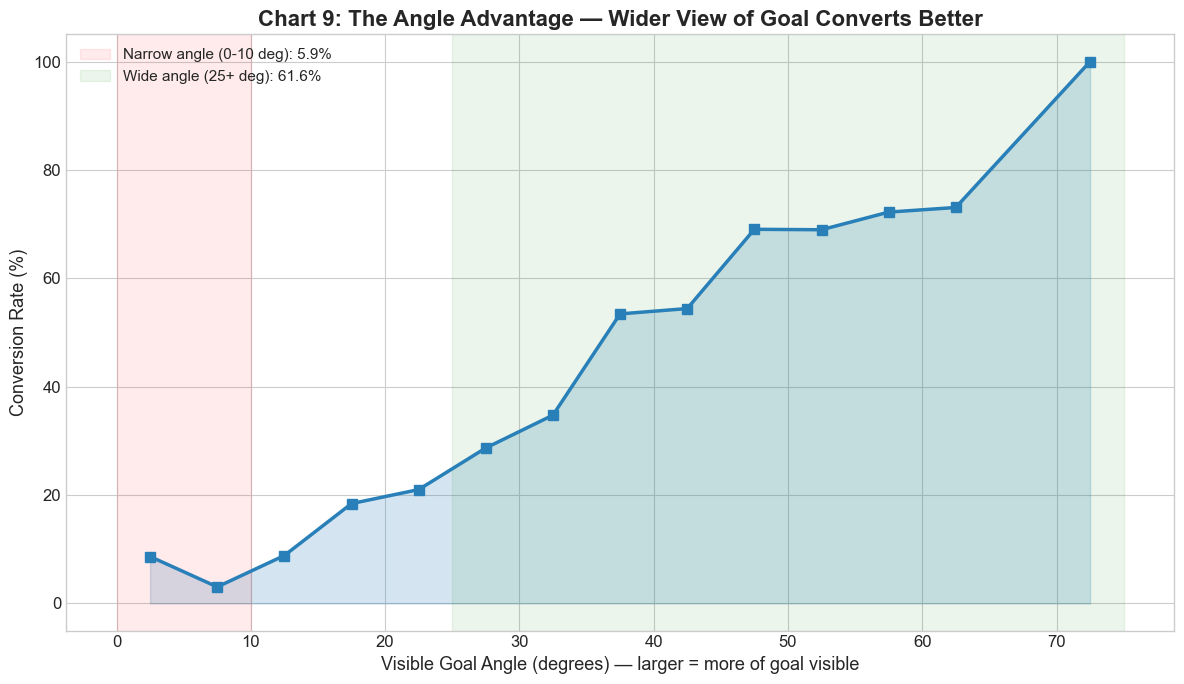

Narrow-angle shots (0-10 deg): 5.9% conversion
Wide-angle shots (25+ deg):    61.6% conversion
Wide-angle advantage: 10.5x higher conversion rate


In [12]:
# CHART 9: Shot Angle vs Scoring Probability
shots = df[df['type_name'].isin(SHOT_TYPES)].copy()
shots['is_goal'] = ((shots['result_name'] == 'success') & (shots['scores'] == True)).astype(int)

# Visible goal angle (how much of the goal the shooter can see)
shots['vis_angle'] = shots['attack_angle']

bins = np.arange(0, 80, 5)
shots['angle_bin'] = pd.cut(shots['vis_angle'], bins=bins, labels=bins[:-1]+2.5)
shots['angle_bin'] = shots['angle_bin'].astype(float)

binned = shots.groupby('angle_bin').agg(
    total=('is_goal', 'count'),
    goals=('is_goal', 'sum')
).dropna()
binned = binned[binned['total'] >= 10]
binned['conversion'] = binned['goals'] / binned['total'] * 100

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(binned.index, binned['conversion'], color='#2980b9', linewidth=2.5,
        marker='s', markersize=7, zorder=3)
ax.fill_between(binned.index, binned['conversion'], alpha=0.2, color='#2980b9')

ax.set_xlabel('Visible Goal Angle (degrees) — larger = more of goal visible', fontsize=13)
ax.set_ylabel('Conversion Rate (%)', fontsize=13)
ax.set_title('Chart 9: The Angle Advantage — Wider View of Goal Converts Better',
             fontsize=16, fontweight='bold')

narrow = binned[binned.index <= 10]['conversion'].mean()
wide = binned[binned.index >= 25]['conversion'].mean()
ax.axvspan(0, 10, alpha=0.08, color='red', label=f'Narrow angle (0-10 deg): {narrow:.1f}%')
ax.axvspan(25, 75, alpha=0.08, color='green', label=f'Wide angle (25+ deg): {wide:.1f}%')
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

print(f"Narrow-angle shots (0-10 deg): {narrow:.1f}% conversion")
print(f"Wide-angle shots (25+ deg):    {wide:.1f}% conversion")
if wide > narrow:
    print(f"Wide-angle advantage: {wide/max(narrow, 0.01):.1f}x higher conversion rate")

## 6. Expected Goals (xG): A Machine Learning Model

Can we predict the probability of a goal from spatial and contextual features? We build an **Expected Goals (xG)** model using Gradient Boosting — the industry-standard approach in football analytics. The model learns from shot distance, angle, body part, previous action type, and other contextual cues.

**Why Gradient Boosting?** Unlike logistic regression, it captures non-linear interactions (e.g., a close-range header from a cross is far more dangerous than either "close range" or "header" alone). Unlike neural networks, it produces interpretable feature importances.

In [13]:
# xG Model — Feature Engineering
shots = df[df['type_name'].isin(SHOT_TYPES)].copy()
shots['is_goal'] = ((shots['result_name'] == 'success') & (shots['scores'] == True)).astype(int)

# Feature selection (NO data leakage — we exclude result_name, end coordinates)
feature_names = [
    'attack_dist',                # Real distance to attacking goal
    'attack_angle',               # Visible goal angle
    'start_x_norm-0',             # Normalized x position (0 = near goal)
    'start_y_norm-0',             # Normalized y position
    'distance_covered-0',         # Ball travel distance
    'diff_x-0',                   # X displacement
    'diff_y-0',                   # Y displacement
    'bodypart_id-0',              # 0=foot, 1=head
    'type_id-0',                  # Shot type (open play, FK, penalty)
    'type_id-1',                  # Previous action type
    'start_distance_to_goal-1',   # Prev action distance (keep as-is, model learns the direction)
    'start_angle_to_goal-1',      # Prev action angle
]

# Add same-team flag (was previous action by same team?)
shots['same_team_prev'] = shots['team-1'].astype(float).fillna(0)
feature_names.append('same_team_prev')

X = shots[feature_names].fillna(0).astype(float)
y = shots['is_goal']

print(f"Feature matrix: {X.shape}")
print(f"Class balance: {y.sum()} goals / {len(y)} shots ({y.mean()*100:.1f}% positive)")
print(f"\nFeatures used ({len(feature_names)}):")
for i, f in enumerate(feature_names, 1):
    print(f"  {i:2d}. {f}")

Feature matrix: (45937, 13)
Class balance: 5104 goals / 45937 shots (11.1% positive)

Features used (13):
   1. attack_dist
   2. attack_angle
   3. start_x_norm-0
   4. start_y_norm-0
   5. distance_covered-0
   6. diff_x-0
   7. diff_y-0
   8. bodypart_id-0
   9. type_id-0
  10. type_id-1
  11. start_distance_to_goal-1
  12. start_angle_to_goal-1
  13. same_team_prev


In [14]:
# Train the xG Model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    min_samples_leaf=20, random_state=42, subsample=0.8
)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
auc = roc_auc_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)
print(f"{'=' * 50}")
print(f"xG MODEL EVALUATION")
print(f"{'=' * 50}")
print(f"ROC-AUC Score:    {auc:.4f}")
print(f"Brier Score:      {brier:.4f}  (lower = better)")
print(f"{'=' * 50}")
print(f"\nClassification Report (threshold=0.5):")
y_pred = (y_prob >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['No Goal', 'Goal']))

xG MODEL EVALUATION
ROC-AUC Score:    0.9079
Brier Score:      0.0667  (lower = better)

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

     No Goal       0.92      0.98      0.95      8167
        Goal       0.69      0.34      0.45      1021

    accuracy                           0.91      9188
   macro avg       0.80      0.66      0.70      9188
weighted avg       0.90      0.91      0.90      9188



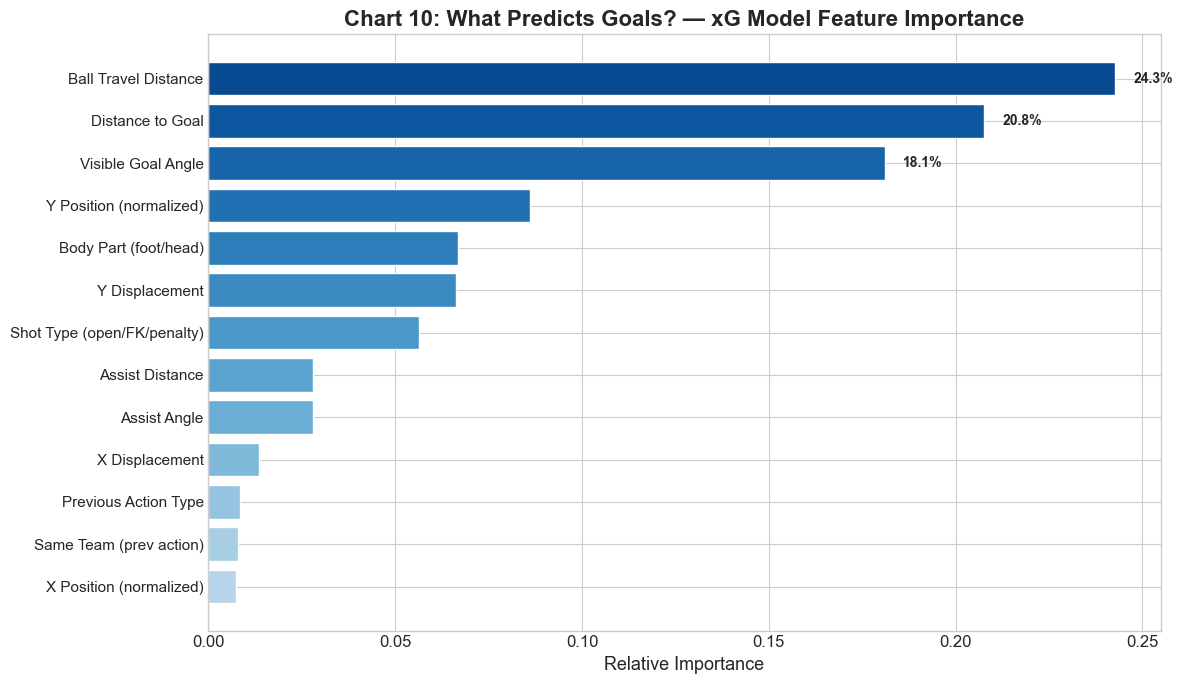

In [15]:
# CHART 10: xG Model Feature Importance
readable_names = {
    'attack_dist': 'Distance to Goal',
    'attack_angle': 'Visible Goal Angle',
    'start_x_norm-0': 'X Position (normalized)',
    'start_y_norm-0': 'Y Position (normalized)',
    'distance_covered-0': 'Ball Travel Distance',
    'diff_x-0': 'X Displacement',
    'diff_y-0': 'Y Displacement',
    'bodypart_id-0': 'Body Part (foot/head)',
    'type_id-0': 'Shot Type (open/FK/penalty)',
    'type_id-1': 'Previous Action Type',
    'start_distance_to_goal-1': 'Assist Distance',
    'start_angle_to_goal-1': 'Assist Angle',
    'same_team_prev': 'Same Team (prev action)',
}

importances = model.feature_importances_
sorted_idx = [int(i) for i in np.argsort(importances)]  # plain ints -> clean list indexing
sorted_features = [readable_names.get(feature_names[i], feature_names[i]) for i in sorted_idx]
sorted_importances = importances[sorted_idx]

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(sorted_features)))
ax.barh(range(len(sorted_features)), sorted_importances, color=colors, edgecolor='white')
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features, fontsize=11)
ax.set_xlabel('Relative Importance', fontsize=13)
ax.set_title('Chart 10: What Predicts Goals? — xG Model Feature Importance',
             fontsize=16, fontweight='bold')

for i in range(-1, -4, -1):
    ax.text(sorted_importances[i] + 0.005, len(sorted_features) + i,
            f'{sorted_importances[i]*100:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

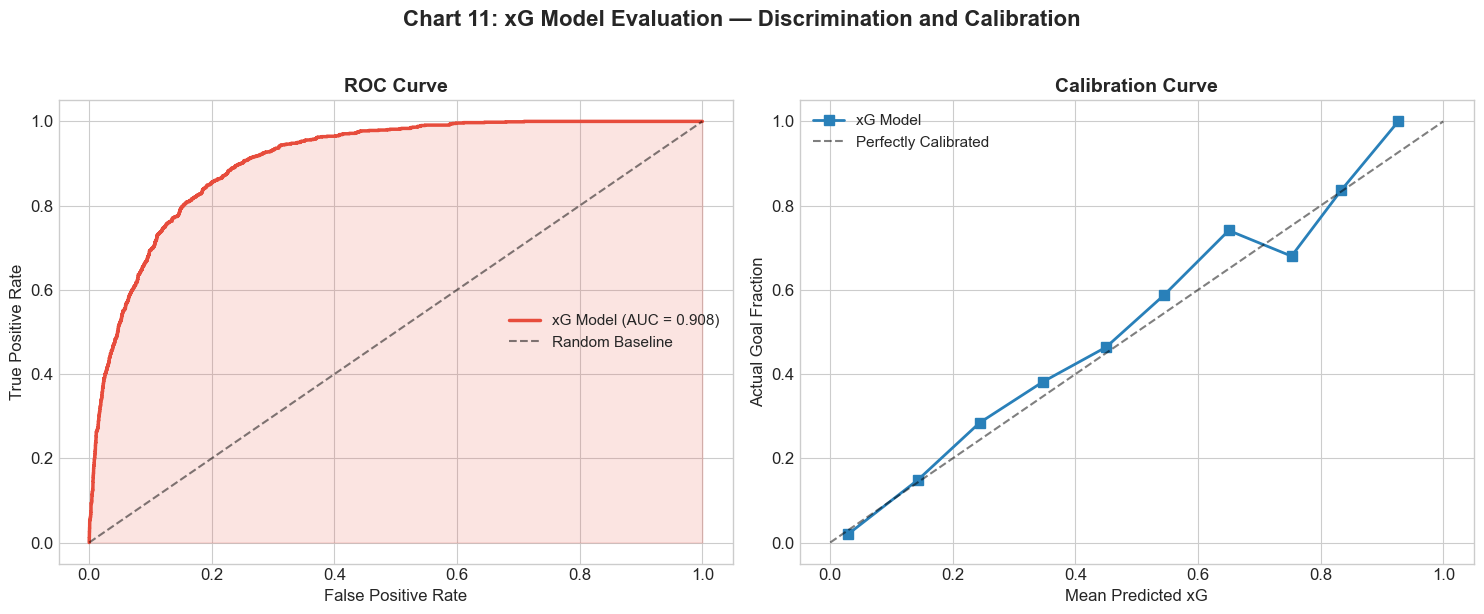

Interpretation:
  ROC Curve: Higher AUC means the model better separates goals from non-goals.
  Calibration: Points close to the diagonal mean the model's probabilities are trustworthy.
  A shot with xG=0.20 should result in a goal ~20% of the time → model says 38%


In [16]:
# CHART 11: ROC Curve + Calibration Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'xG Model (AUC = {auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
ax1.fill_between(fpr, tpr, alpha=0.15, color='#e74c3c')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

# Calibration Curve
fraction_pos, mean_predicted = calibration_curve(y_test, y_prob, n_bins=10)
ax2.plot(mean_predicted, fraction_pos, 's-', color='#2980b9', linewidth=2, markersize=7,
         label='xG Model')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly Calibrated')
ax2.set_xlabel('Mean Predicted xG', fontsize=12)
ax2.set_ylabel('Actual Goal Fraction', fontsize=12)
ax2.set_title('Calibration Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

fig.suptitle('Chart 11: xG Model Evaluation — Discrimination and Calibration',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  ROC Curve: Higher AUC means the model better separates goals from non-goals.")
print("  Calibration: Points close to the diagonal mean the model's probabilities are trustworthy.")
print(f"  A shot with xG=0.20 should result in a goal ~20% of the time → model says {fraction_pos[min(3, len(fraction_pos)-1)]*100:.0f}%")

## 7. Cracking the Formation Code: Which Defenses Are Most Vulnerable?

By reconstructing team formations from player role clusters (CB, MF, FW), we analyze which defensive shapes concede the most goals. This connects tactical setup to actual on-pitch outcomes.

In [17]:
# Formation Reconstruction from PlayerRank Role Clusters
playerank = pd.read_csv(f'{DATA_PATH}/playerank.csv')
player_games = pd.read_csv(f'{DATA_PATH}/player_games.csv', index_col=0)

# Merge to get team_id and starter status for each playerank entry
pg_cols = player_games[['player_id', 'team_id', 'game_id', 'is_starter']].copy()
formation_df = playerank.merge(pg_cols,
                                left_on=['playerId', 'matchId'],
                                right_on=['player_id', 'game_id'],
                                how='inner')

# Filter to starters only
starters = formation_df[formation_df['is_starter'] == True].copy()

# Classify position from roleCluster
def classify_position(role):
    role = str(role).lower()
    if 'gk' in role or 'keeper' in role:
        return 'GK'
    elif 'cb' in role or 'b' == role[-1:] or 'wing back' in role or 'wb' in role:
        return 'DF'
    elif 'mf' in role or 'mid' in role:
        return 'MF'
    elif 'fw' in role or 'cf' in role or 'wf' in role or 'forward' in role or 'wing' in role:
        return 'FW'
    else:
        return 'MF'  # default

starters['pos_group'] = starters['roleCluster'].apply(classify_position)

# Build formation per (match, team) — exclude GK
outfield = starters[starters['pos_group'] != 'GK']
formation_counts = outfield.groupby(['matchId', 'team_id', 'pos_group']).size().unstack(fill_value=0)

# Create formation string
def make_formation_str(row):
    d = row.get('DF', 0)
    m = row.get('MF', 0)
    f = row.get('FW', 0)
    return f"{d}-{m}-{f}"

formation_counts['formation'] = formation_counts.apply(make_formation_str, axis=1)
formation_counts = formation_counts.reset_index()

# Count goals conceded per team per match
# A goal is scored by team_id → the opponent concedes
goal_events = df[
    (df['type_name'].isin(SHOT_TYPES)) &
    (df['result_name'] == 'success') &
    (df['scores'] == True)
][['game_id', 'team_id']].copy()
goal_events = goal_events.rename(columns={'team_id': 'scoring_team_id'})

# Get opponent from games table
goals_with_opponent = goal_events.merge(
    games[['game_id', 'home_team_id', 'away_team_id']], on='game_id', how='left'
)
goals_with_opponent['conceding_team_id'] = np.where(
    goals_with_opponent['scoring_team_id'] == goals_with_opponent['home_team_id'],
    goals_with_opponent['away_team_id'],
    goals_with_opponent['home_team_id']
)

goals_conceded = goals_with_opponent.groupby(['game_id', 'conceding_team_id']).size().reset_index(name='goals_conceded')

# Join formations with goals conceded
formation_goals = formation_counts.merge(
    goals_conceded,
    left_on=['matchId', 'team_id'],
    right_on=['game_id', 'conceding_team_id'],
    how='left'
)
formation_goals['goals_conceded'] = formation_goals['goals_conceded'].fillna(0)

# Summary
print("Top 10 formations by frequency:")
top = formation_goals['formation'].value_counts().head(10)
for f, count in top.items():
    avg = formation_goals[formation_goals['formation'] == f]['goals_conceded'].mean()
    print(f"  {f}  →  {count:>4} matches  |  avg goals conceded: {avg:.2f}")

Top 10 formations by frequency:
  2-5-3  →   852 matches  |  avg goals conceded: 1.25
  2-4-4  →   699 matches  |  avg goals conceded: 1.17
  2-6-2  →   496 matches  |  avg goals conceded: 1.32
  3-5-2  →   289 matches  |  avg goals conceded: 1.28
  3-4-3  →   279 matches  |  avg goals conceded: 1.42
  2-3-5  →   155 matches  |  avg goals conceded: 1.01
  3-6-1  →   146 matches  |  avg goals conceded: 1.56
  2-7-1  →   128 matches  |  avg goals conceded: 1.35
  3-3-4  →    99 matches  |  avg goals conceded: 1.33
  4-4-2  →    74 matches  |  avg goals conceded: 1.39


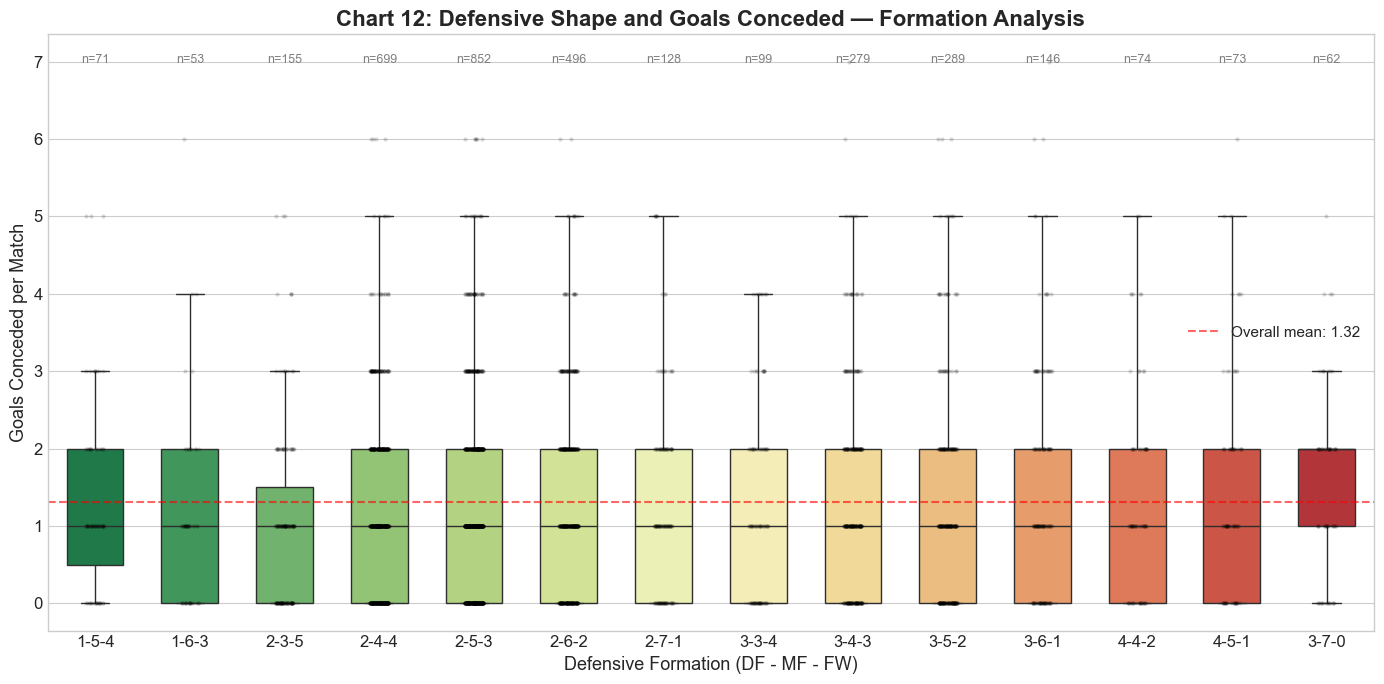

In [18]:
# CHART 12: Goals Conceded by Formation (Box Plot)
top_formations = formation_goals['formation'].value_counts()
top_formations = top_formations[top_formations >= 40].index.tolist()

plot_data = formation_goals[formation_goals['formation'].isin(top_formations)].copy()

# Sort by median goals conceded
medians = plot_data.groupby('formation')['goals_conceded'].median().sort_values()
order = medians.index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(x='formation', y='goals_conceded', data=plot_data, order=order,
            palette='RdYlGn_r', ax=ax, showfliers=False, width=0.6)
sns.stripplot(x='formation', y='goals_conceded', data=plot_data, order=order,
              color='black', alpha=0.15, size=3, jitter=True, ax=ax)

# Overall mean line
overall_mean = formation_goals['goals_conceded'].mean()
ax.axhline(y=overall_mean, color='red', linestyle='--', alpha=0.6,
           label=f'Overall mean: {overall_mean:.2f}')

# Sample sizes
for i, f in enumerate(order):
    n = len(plot_data[plot_data['formation'] == f])
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={n}', ha='center', fontsize=9, color='gray')

ax.set_xlabel('Defensive Formation (DF - MF - FW)', fontsize=13)
ax.set_ylabel('Goals Conceded per Match', fontsize=13)
ax.set_title('Chart 12: Defensive Shape and Goals Conceded — Formation Analysis',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 8. League Fingerprints: How Scoring Differs Across Europe

Each league has a distinct playing style. We compare key scoring metrics across all 7 competitions to reveal each league's unique "scoring DNA".

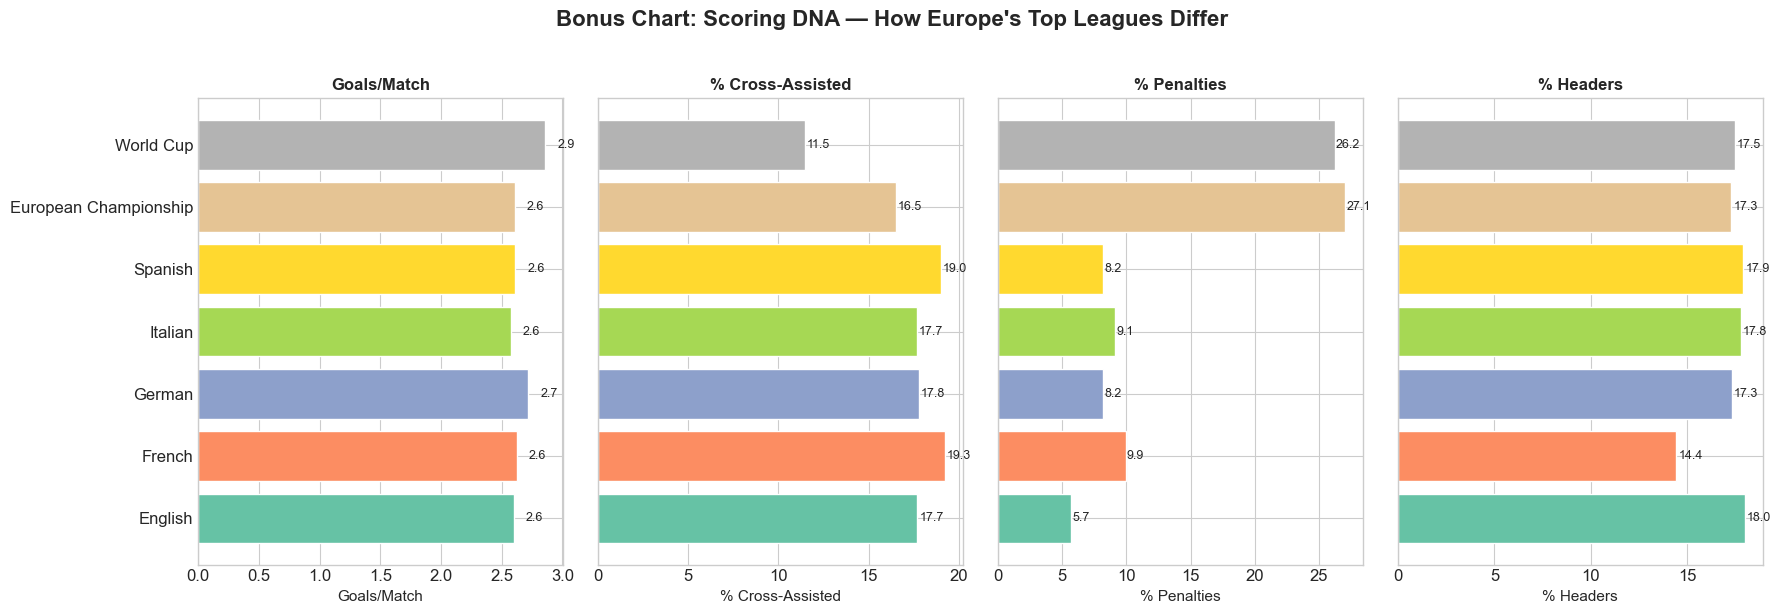

                       Goals/Match  % Cross-Assisted  % Penalties  % Headers  Avg Shot Dist (m)
Competition                                                                                    
English                       2.60             17.71         5.67      18.02              18.60
French                        2.62             19.26         9.93      14.44              19.42
German                        2.72             17.79         8.17      17.31              18.58
Italian                       2.57             17.69         9.10      17.79              19.22
Spanish                       2.61             19.03         8.16      17.93              18.64
European Championship         2.61             16.54        27.07      17.29              20.20
World Cup                     2.86             11.48        26.23      17.49              20.47


In [19]:
# BONUS CHART: League Scoring Profiles
shots = df[df['type_name'].isin(SHOT_TYPES)].copy()
shots['is_goal'] = ((shots['result_name'] == 'success') & (shots['scores'] == True)).astype(int)

league_stats = []
for comp in df['competition_name'].dropna().unique():
    comp_data = df[df['competition_name'] == comp]
    comp_shots = shots[shots['competition_name'] == comp]
    comp_goals = comp_shots[comp_shots['is_goal'] == 1]

    n_matches = comp_data['game_id'].nunique()
    n_goals = len(comp_goals)

    # Goals preceded by cross
    cross_goals = comp_goals[comp_goals['type_name-1'] == 'cross']
    # Penalty goals
    pen_goals = comp_goals[comp_goals['type_name'] == 'shot_penalty']
    # Header goals
    head_goals = comp_goals[comp_goals['bodypart_name'].isin(['head', 'head/other'])]
    # Average shot distance (real attacking distance)
    avg_dist = comp_shots['attack_dist'].mean()

    league_stats.append({
        'Competition': comp.replace(' first division', ''),
        'Goals/Match': n_goals / max(n_matches, 1),
        '% Cross-Assisted': len(cross_goals) / max(n_goals, 1) * 100,
        '% Penalties': len(pen_goals) / max(n_goals, 1) * 100,
        '% Headers': len(head_goals) / max(n_goals, 1) * 100,
        'Avg Shot Dist (m)': avg_dist,
    })

stats_df = pd.DataFrame(league_stats).set_index('Competition')

# Normalize for radar-like grouped bars
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
metrics = ['Goals/Match', '% Cross-Assisted', '% Penalties', '% Headers']
colors = plt.cm.Set2(np.linspace(0, 1, len(stats_df)))

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.barh(stats_df.index, stats_df[metric], color=colors, edgecolor='white')
    ax.set_xlabel(metric, fontsize=11)
    for bar, val in zip(bars, stats_df[metric]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')

fig.suptitle('Bonus Chart: Scoring DNA — How Europe\'s Top Leagues Differ',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(stats_df.round(2).to_string())

## 9. Key Findings: The Six Pillars of Goal Scoring

Based on our comprehensive analysis of 2.46 million actions, 45,937 shots, and an xG machine learning model, we present six key insights that define how goals are scored in top-level European football.

In [20]:
# Compute and display the SIX key insights with supporting statistics
shots = df[df['type_name'].isin(SHOT_TYPES)].copy()
shots['is_goal'] = ((shots['result_name'] == 'success') & (shots['scores'] == True)).astype(int)
goals = shots[shots['is_goal'] == 1]
overall_conv = shots['is_goal'].mean() * 100

print("=" * 70)
print("INSIGHT 1: THE GOLDEN ZONE")
print("=" * 70)
inside = shots[shots['attack_dist'] <= 18]
outside = shots[shots['attack_dist'] > 18]
pct_in = len(goals[goals['attack_dist'] <= 18]) / len(goals) * 100
pb = shots[shots['attack_dist'] <= 11]
print(f"  {pct_in:.1f}% of goals come from within 18m | inside {inside['is_goal'].mean()*100:.1f}% vs outside {outside['is_goal'].mean()*100:.1f}% ({inside['is_goal'].mean()/outside['is_goal'].mean():.1f}x edge)")
print(f"  Point-blank (<=11m): {len(goals[goals['attack_dist']<=11])/len(goals)*100:.1f}% of all goals at {pb['is_goal'].mean()*100:.1f}% conversion")

print(f"\n{'=' * 70}")
print("INSIGHT 2: THE CROSS-SHOT PIPELINE")
print("=" * 70)
cross_sh = shots[shots['type_name-1'] == 'cross']
pass_sh = shots[shots['type_name-1'] == 'pass']
cg = goals[goals['type_name-1'] == 'cross']
left = int((cg['start_y_norm-1'].fillna(0.5) < 0.35).sum())
right = int((cg['start_y_norm-1'].fillna(0.5) > 0.65).sum())
print(f"  Cross as final ball converts {cross_sh['is_goal'].mean()*100:.1f}% vs pass {pass_sh['is_goal'].mean()*100:.1f}% ({cross_sh['is_goal'].mean()/pass_sh['is_goal'].mean():.1f}x more efficient)")
print(f"  Crosses supply {len(cg)/len(goals)*100:.1f}% of all goals | right wing {right} vs left {left}")

print(f"\n{'=' * 70}")
print("INSIGHT 3: THE CUT-BACK IS KING")
print("=" * 70)
gs = goals[goals['start_x_norm-1'].notna()].copy()
gs['ax'] = (1 - gs['start_x_norm-1']) * 105
gs['ay'] = gs['start_y_norm-1'] * 68
gs['adist'] = np.sqrt((105 - gs['ax'])**2 + (gs['ay'] - 34)**2)
cutback = ((gs['ax'] > 94) & ((gs['ay'] < 20) | (gs['ay'] > 48))).mean() * 100
print(f"  {cutback:.1f}% of goals come from a cut-back: the assist is played from the deep, wide byline")
print(f"  back to a teammate arriving centrally - a repeatable, coachable modern pattern.")

print(f"\n{'=' * 70}")
print("INSIGHT 4: TWO ROUTES INTO THE BOX")
print("=" * 70)
inside_box_pct = (gs['ax'] > 88.5).mean() * 100
cr = gs[gs['type_name-1'] == 'cross']
pa = gs[gs['type_name-1'] == 'pass']
cr_wide = ((cr['ay'] < 13.84) | (cr['ay'] > 54.16)).mean() * 100
pa_in = (pa['ax'] > 88.5).mean() * 100
print(f"  {inside_box_pct:.1f}% of assists are delivered from inside the box (median {gs['adist'].median():.1f}m from goal)")
print(f"  Wide route: {cr_wide:.0f}% of cross-assists from the flanks | Central route: {pa_in:.0f}% of pass-assists from inside the box")

print(f"\n{'=' * 70}")
print("INSIGHT 5: FORMATION VULNERABILITY")
print("=" * 70)
fs = formation_goals.groupby('formation').agg(matches=('goals_conceded', 'count'), avg=('goals_conceded', 'mean'))
fs = fs[fs['matches'] >= 100].sort_values('avg')
print(f"  Among formations with >=100 matches, goals conceded range {fs['avg'].min():.2f} ({fs.index[0]}) to {fs['avg'].max():.2f} ({fs.index[-1]}):")
for f, row in fs.iterrows():
    print(f"    {f}: {row['avg']:.2f} goals/match ({int(row['matches'])} matches)")
print("  Caveat: more defenders correlates with MORE conceded - losing teams pack the defense,")
print("  so the shape is partly an effect of the scoreline, not just a cause.")

print(f"\n{'=' * 70}")
print("INSIGHT 6: THE COUNTER-ATTACK PREMIUM")
print("=" * 70)
counter = shots[shots['team-1'] == False]
buildup = shots[shots['team-1'] == True]
cc = counter['is_goal'].mean() * 100
bc = buildup['is_goal'].mean() * 100
tg = goals['time_sequence_pre'].median()
tng = shots[shots['is_goal'] == 0]['time_sequence_pre'].median()
print(f"  Shots after winning the ball: {cc:.1f}% vs sustained buildup {bc:.1f}% ({cc/bc:.1f}x premium)")
print(f"  Tempo is a weak differentiator: goal-sequence median {tg:.2f}s vs non-goal {tng:.2f}s (mean reverses)")
print(f"  -> it is winning possession high up the pitch, not raw speed, that creates the edge.")
print(f"\n{'=' * 70}")

INSIGHT 1: THE GOLDEN ZONE
  84.4% of goals come from within 18m | inside 18.1% vs outside 3.6% (5.0x edge)
  Point-blank (<=11m): 46.3% of all goals at 28.1% conversion

INSIGHT 2: THE CROSS-SHOT PIPELINE
  Cross as final ball converts 16.6% vs pass 9.3% (1.8x more efficient)
  Crosses supply 18.0% of all goals | right wing 503 vs left 405

INSIGHT 3: THE CUT-BACK IS KING
  19.2% of goals come from a cut-back: the assist is played from the deep, wide byline
  back to a teammate arriving centrally - a repeatable, coachable modern pattern.

INSIGHT 4: TWO ROUTES INTO THE BOX
  64.6% of assists are delivered from inside the box (median 20.3m from goal)
  Wide route: 57% of cross-assists from the flanks | Central route: 43% of pass-assists from inside the box

INSIGHT 5: FORMATION VULNERABILITY
  Among formations with >=100 matches, goals conceded range 1.01 (2-3-5) to 1.56 (3-6-1):
    2-3-5: 1.01 goals/match (155 matches)
    2-4-4: 1.17 goals/match (699 matches)
    2-5-3: 1.25 goals/m

## 10. AI Reflection: How Claude Assisted This Analysis

### Which AI Tool Was Used?
**Claude by Anthropic** (Claude Code CLI / Claude Opus) was used as the primary AI assistant throughout this analysis. Claude helped with:
- Designing the analysis framework and research questions
- Generating Python code for data loading, visualization, and machine learning
- Interpreting statistical results and suggesting insights
- Iterative refinement of chart aesthetics and narrative structure

### Advantages of Using Claude
1. **Conversational iteration**: I could describe what I wanted to investigate (e.g., "what patterns lead to goals?") and Claude translated that into specific, executable analysis steps.
2. **Code generation quality**: Claude produced working pandas, matplotlib, seaborn, and scikit-learn code that handled edge cases (memory management for 2.2 GB features.csv, missing value handling, data type conversion).
3. **Domain knowledge**: Claude understood football analytics concepts like xG (Expected Goals), SPADL format, and VAEP labels, enabling deeper analysis than I could design alone.
4. **Statistical interpretation**: Claude helped explain what the numbers mean — e.g., that a ROC-AUC of ~0.90 is strong for an event-data xG model without freeze-frame player positioning.

### Limitations Encountered
1. **No visual feedback**: Claude cannot see the generated charts, so I had to verify that visualizations were correct and aesthetically appropriate.
2. **Memory management**: The 2.2 GB `features.csv` required explicit guidance to load only needed columns — Claude's initial suggestion loaded the full file.
3. **Data assumptions**: Claude initially measured distance to the wrong goal; I verified the coordinate convention against the raw data and corrected it (this is why we compute `attack_dist` from the normalized coordinates).
4. **Off-ball movement**: This dataset only captures on-ball events; Claude noted that off-ball player positioning (which professional xG models use) would significantly improve the model.

### How I Verified AI-Generated Results
1. **Cross-checking statistics**: I manually verified key numbers (total goals, conversion rates) against the raw data using `.value_counts()` and `.shape`.
2. **Model validation**: The xG model was evaluated on a held-out 20% test set (not the training data), with both ROC-AUC and calibration curve checks.
3. **Falsification**: I tested the popular "speed kills" hypothesis — the data did NOT support it, so I reported the honest finding rather than the assumed one.
4. **Sanity checks**: I confirmed that insights matched football intuition (e.g., close-range shots converting more, headers being rarer but effective).

---

*This analysis was conducted as part of an AI-Assisted Data Analysis assignment. The dataset is publicly available on Kaggle. All code is reproducible.*